In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

df = pd.DataFrame({
    "Cus_ID": np.arange(301219, 301219 + n),
    "Sex": np.random.choice(["M", "F"], n),
    "Age": np.random.randint(18, 61, n),
    "Income": np.random.randint(300000, 2800000, n),
    "Rating": np.random.randint(1, 101, n)
})

# Sort by income (optional, makes it look like the screenshot)
df = df.sort_values("Income").reset_index(drop=True)

print(df.head())

# Save to CSV
df.to_csv("Amazon.com Clustring Model.csv", index=False)

   Cus_ID Sex  Age  Income  Rating
0  301264   F   49  303051       1
1  301358   M   35  303267      59
2  301398   M   46  305486      39
3  301305   F   53  309435      74
4  301413   M   35  338102      23


In [2]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [4]:
data = pd.read_csv("/kaggle/working/Amazon.com Clustring Model.csv")

In [5]:
x=data.iloc[:, [2,4]].values

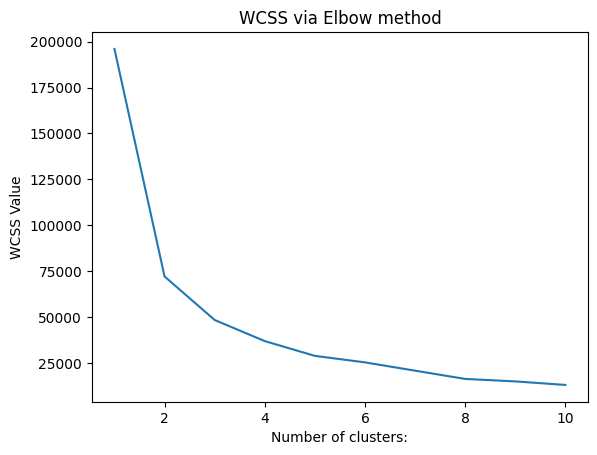

In [10]:
wcss=[]
for i in range (1,11) :
    model=KMeans (n_clusters=i, init='k-means++', random_state=21)
    model.fit(x)
    wcss.append (model.inertia_)
plt.plot (range(1,11),wcss)
plt.title('WCSS via Elbow method')
plt.xlabel('Number of clusters:')
plt.ylabel('WCSS Value')
plt.show()

In [12]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_means=model.fit_predict(x)
print("y_means:\n\n", y_means)

y_means:

 [3 0 1 2 3 3 1 1 3 2 2 0 2 0 2 2 2 1 2 3 1 1 3 0 1 0 1 0 2 1 0 1 0 3 3 0 3
 3 1 2 3 3 1 2 3 2 3 3 2 3 1 3 3 3 3 2 0 3 2 3 0 2 2 3 2 0 1 2 3 3 1 2 3 1
 0 1 1 2 2 1 1 3 3 2 1 1 1 1 2 0 1 3 1 1 3 0 3 1 2 1 1 1 2 3 3 2 3 3 1 1 1
 3 2 3 1 0 3 3 1 1 3 2 2 0 1 1 1 3 3 0 1 3 3 3 3 3 1 1 2 2 3 1 0 1 1 3 3 2
 1 2 3 3 1 1 1 0 2 1 0 1 0 0 3 0 2 3 0 2 0 1 3 3 3 3 2 2 3 3 3 1 0 3 0 0 2
 1 3 3 2 3 0 3 3 1 3 3 2 3 2 3]


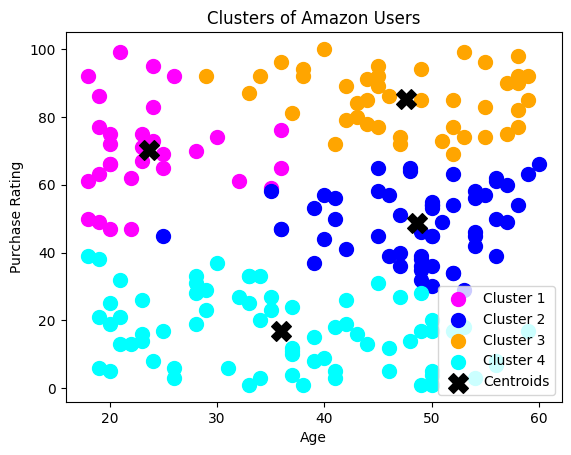

In [18]:
plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s=100, c='magenta', label='Cluster 1')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s=100, c='orange', label='Cluster 3')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s=100, c='cyan', label='Cluster 4')

# Plot the centroids
plt.scatter(model.cluster_centers_[:, 0],
            model.cluster_centers_[:, 1],
            s=200,
            c='black',
            marker='X',
            label='Centroids')

plt.title('Clusters of Amazon Users')
plt.xlabel('Age')
plt.ylabel('Purchase Rating')
plt.legend()
plt.show()